In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from Bio import SeqIO
from io import StringIO

In [36]:
def get_sequence_from_uniprot(uniprot_id, max_retries=5):
    """Function to retrieve protein sequences from UniProt"""
    
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"

    session = requests.Session()
    retry_strategy = Retry(
        total=max_retries,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Python/3.13 Protein-Sequence-Retrieval"
    }

    try:
        response = session.get(url, headers=headers, timeout=30)
        if response.status_code == 200:
            fasta = StringIO(response.text)
            for record in SeqIO.parse(fasta, "fasta"):
                return str(record.seq)
        else:
            print(
                f"Failed to retrieve sequence for {uniprot_id}, status code: {response.status_code}"
            )
    except Exception as e:
        print(f"Error retrieving sequence for {uniprot_id}: {str(e)}")

    return None


# Function to load UniProt database from local FASTA file
def load_local_uniprot_database(fasta_file="uniprot_sprot.fasta"):
    
    print("Loading local UniProt database...")
    uniprot_dict = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        uniprot_id = record.id.split("|")[1] if "|" in record.id else record.id
        uniprot_dict[uniprot_id] = str(record.seq)
    print(f"Loaded {len(uniprot_dict)} sequences from local database")
    return uniprot_dict


# Process UniProt IDs and retrieve sequences
def process_uniprot_ids():
    """
    Process UniProt IDs from input file, retrieve sequences,
    and save results to output file
    """
    try:
        data = pd.read_csv("1temp.tsv", sep="\t")

        unique_uniprot_ids = data["UniProt_ID"].unique()

        uniprot_dict = load_local_uniprot_database()

        found_sequences = {}
        for uniprot_id in unique_uniprot_ids:
            if uniprot_id in uniprot_dict:
                found_sequences[uniprot_id] = uniprot_dict[uniprot_id]
            else:
                print(f"Sequence for {uniprot_id} not found in local database")

        data["Protein_Sequence"] = data["UniProt_ID"].map(found_sequences)

        data.to_csv("1temp_with_sequences.tsv", sep="\t", index=False)

        print(f"Processed {len(found_sequences)} unique UniProt IDs")
        print(
            f"Success rate: {len(found_sequences)}/{len(unique_uniprot_ids)} ({len(found_sequences)/len(unique_uniprot_ids)*100:.1f}%)"
        )

    except Exception as e:
        print(f"An error occurred during processing: {str(e)}")

# Run the processing function
process_uniprot_ids()


Loading local UniProt database...
Loaded 572970 sequences from local database
Sequence for W0TJ64 not found in local database
Sequence for Q8GB52 not found in local database
Sequence for Q40059 not found in local database
Sequence for P96988 not found in local database
Sequence for Q3HWZ5 not found in local database
Sequence for O00095 not found in local database
Sequence for Q9REI6 not found in local database
Sequence for Q8NJY3 not found in local database
Sequence for B8YLY0 not found in local database
Sequence for Q7SIG1 not found in local database
Sequence for Q9R782 not found in local database
Sequence for R9S082 not found in local database
Sequence for - not found in local database
Sequence for Q9EYL5 not found in local database
Sequence for Q56013 not found in local database
Sequence for Q2XSL7 not found in local database
Sequence for Q72SM7 not found in local database
Sequence for Q25252 not found in local database
Sequence for Q5KZ26 not found in local database
Sequence for O2

In [37]:
input_file = "1temp_with_sequences.tsv"
output_file = "1temp_with_sequences_filtered.tsv"

df = pd.read_csv(input_file, sep="\t")
total_rows = len(df)

df_filtered = df.dropna(subset=["Protein_Sequence"])
df_filtered = df_filtered[df_filtered["Protein_Sequence"].str.strip() != ""]

filtered_rows = len(df_filtered)
removed_rows = total_rows - filtered_rows

df_filtered.to_csv(output_file, sep="\t", index=False)

print(f"Total rows in original file: {total_rows}")
print(f"Rows removed (no sequence): {removed_rows}")
print(f"Rows remaining: {filtered_rows}")
print(f"Filtered data saved to {output_file}")

Total rows in original file: 14695
Rows removed (no sequence): 781
Rows remaining: 13914
Filtered data saved to 1temp_with_sequences_filtered.tsv


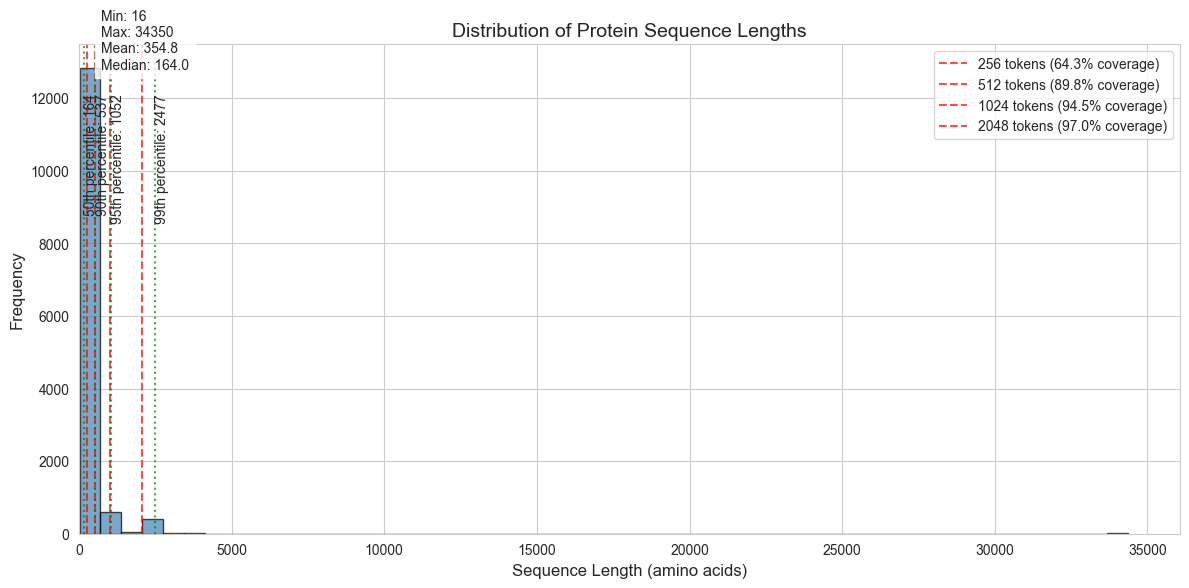

In [38]:
def plot_sequence_length_distribution(file_path):
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6))

    df = pd.read_csv(file_path, sep="\t", header=None)

    sequence_col = df.iloc[:, -1]
    sequence_lengths = sequence_col.str.len()

    plt.hist(sequence_lengths, bins=50, alpha=0.7, color="steelblue", edgecolor="black")

    common_lengths = [256, 512, 1024, 2048]
    for length in common_lengths:
        plt.axvline(
            x=length,
            color="red",
            linestyle="--",
            alpha=0.7,
            label=f"{length} tokens" if length == common_lengths[0] else f"{length}",
        )

    percentiles = [50, 90, 95, 99]
    percentile_values = np.percentile(sequence_lengths, percentiles)

    for p, val in zip(percentiles, percentile_values):
        plt.axvline(x=val, color="green", linestyle=":", alpha=0.7)
        plt.text(
            val + 10,
            plt.gca().get_ylim()[1] * 0.9,
            f"{p}th percentile: {int(val)}",
            rotation=90,
            verticalalignment="top",
        )

    coverage = {}
    for length in common_lengths:
        coverage[length] = (sequence_lengths <= length).mean() * 100

    coverage_labels = [
        f"{length} tokens ({coverage[length]:.1f}% coverage)" for length in common_lengths
    ]
    plt.legend(coverage_labels, loc="upper right")

    plt.xlabel("Sequence Length (amino acids)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Protein Sequence Lengths", fontsize=14)

    stats_text = (
        f"Min: {sequence_lengths.min()}\n"
        f"Max: {sequence_lengths.max()}\n"
        f"Mean: {sequence_lengths.mean():.1f}\n"
        f"Median: {sequence_lengths.median()}"
    )
    plt.text(
        0.02,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.xlim(left=0)

    plt.tight_layout()
    plt.show()


plot_sequence_length_distribution("1temp_with_sequences_filtered.tsv")

Total sequences: 13915
Sequences within length limit (1024): 13155
Sequences removed: 760 (5.46%)
Filtered data saved to: sequences_filtered_1024.tsv


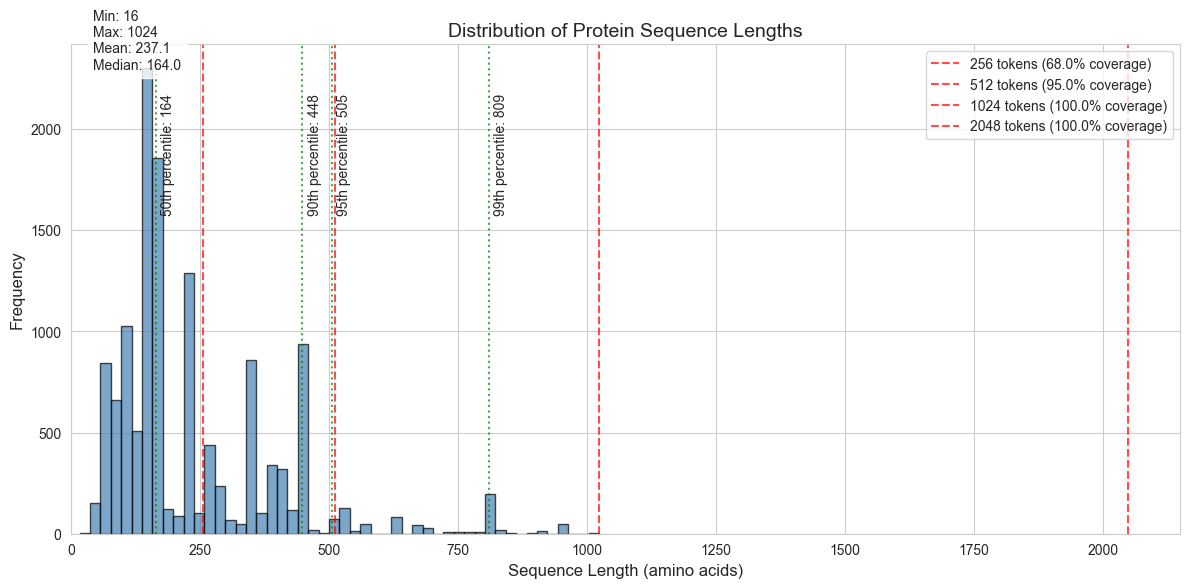

In [39]:
file_path = '1temp_with_sequences_filtered.tsv'
df = pd.read_csv(file_path, sep='\t', header=None)

sequence_col = df.iloc[:, -1]

sequence_lengths = sequence_col.str.len()

max_length = 1024
filtered_df = df[sequence_lengths <= max_length]

output_file = 'sequences_filtered_1024.tsv'
filtered_df.to_csv(output_file, sep='\t', header=False, index=False)

total_sequences = len(df)
filtered_sequences = len(filtered_df)
removed_sequences = total_sequences - filtered_sequences

print(f"Total sequences: {total_sequences}")
print(f"Sequences within length limit ({max_length}): {filtered_sequences}")
print(f"Sequences removed: {removed_sequences} ({removed_sequences/total_sequences*100:.2f}%)")
print(f"Filtered data saved to: {output_file}")

plot_sequence_length_distribution(output_file)

In [43]:
df = pd.read_csv('sequences_filtered_1024.tsv', sep='\t')

found = False
for idx, row in df.iterrows():
    if row['SEC_STR'] == '-4.38':
        df.at[idx, 'SEC_STR'] = "Coil"
        found = True

if found:
    df.to_csv('sequences_filtered_1024.tsv', sep='\t', index=False)
    print("File saved with the corrected SEC_STR value.")
else:
    print("No entry found with SEC_STR value = -4.38")

No entry found with SEC_STR value = -4.38
